In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [42]:
df = pd.read_csv(r"/ford.csv")

In [43]:
df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,Fiesta,2017,12000,Automatic,15944,Petrol,150,57.7,1.0
1,Focus,2018,14000,Manual,9083,Petrol,150,57.7,1.0
2,Focus,2017,13000,Manual,12456,Petrol,150,57.7,1.0
3,Fiesta,2019,17500,Manual,10460,Petrol,145,40.3,1.5
4,Fiesta,2019,16500,Automatic,1482,Petrol,145,48.7,1.0


In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17966 entries, 0 to 17965
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         17966 non-null  object 
 1   year          17966 non-null  int64  
 2   price         17966 non-null  int64  
 3   transmission  17966 non-null  object 
 4   mileage       17966 non-null  int64  
 5   fuelType      17966 non-null  object 
 6   tax           17966 non-null  int64  
 7   mpg           17966 non-null  float64
 8   engineSize    17966 non-null  float64
dtypes: float64(2), int64(4), object(3)
memory usage: 1.2+ MB


In [45]:
df.describe()

,year,price,mileage,tax,mpg,engineSize
count,17966.000000,17966.000000,17966.000000,17966.000000,17966.000000,17966.000000
mean,2016.866470,12279.534844,23362.608761,113.329456,57.906980,1.350807
std,2.050336,4741.343657,19472.054349,62.012456,10.125696,0.432367
min,1996.000000,495.000000,1.000000,0.000000,20.800000,0.000000
25%,2016.000000,8999.000000,9987.000000,30.000000,52.300000,1.000000
50%,2017.000000,11291.000000,18242.500000,145.000000,58.900000,1.200000
75%,2018.000000,15299.000000,31060.000000,145.000000,65.700000,1.500000
max,2060.000000,54995.000000,177644.000000,580.000000,201.800000,5.000000


In [46]:
df.isna().sum()

,0
model,0
year,0
price,0
transmission,0
mileage,0
fuelType,0
tax,0
mpg,0
engineSize,0


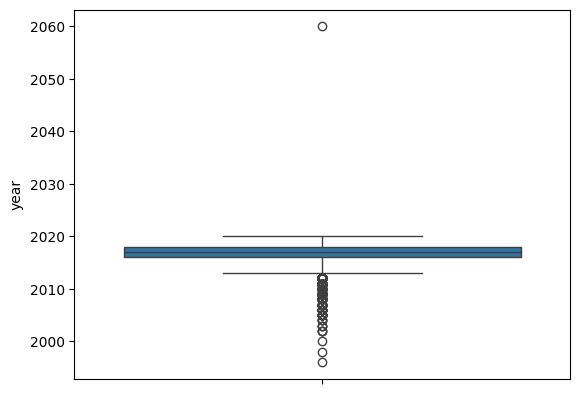

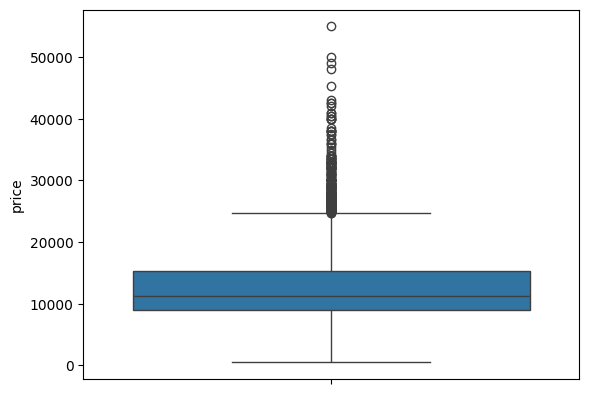

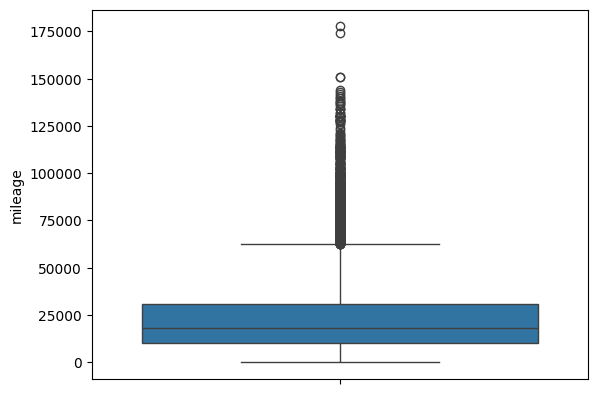

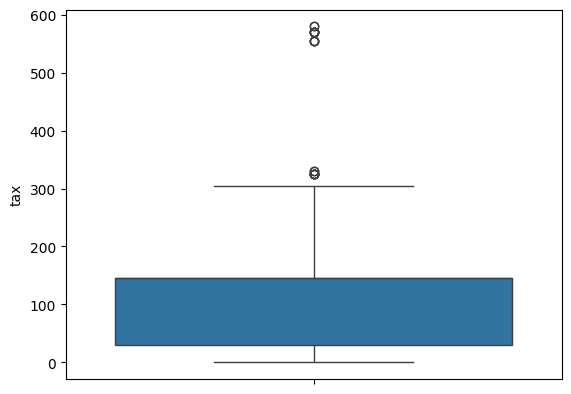

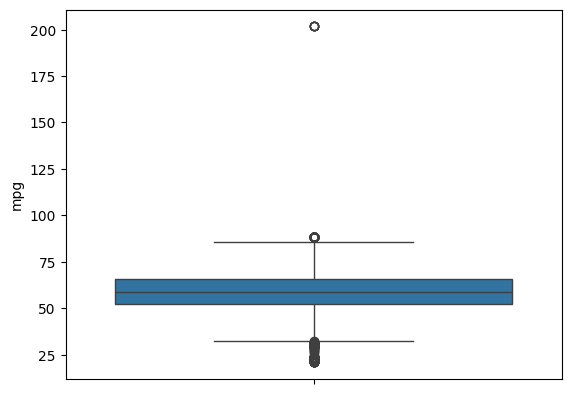

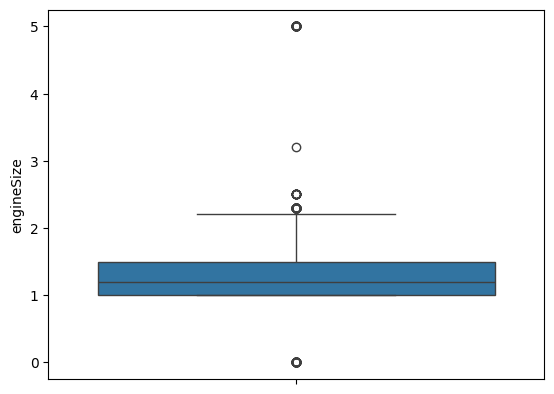

In [47]:
for i in df.select_dtypes(include = "number"):
  sns.boxplot(df[i])
  plt.show()

<Axes: >

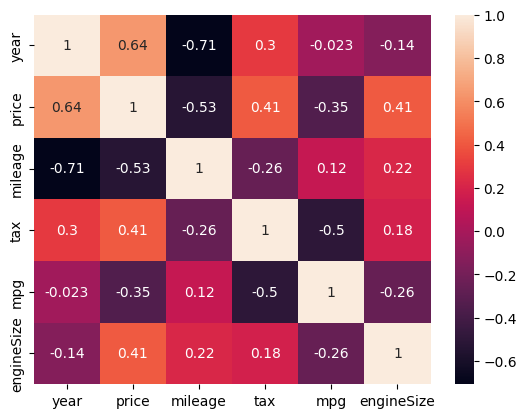

In [48]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

In [49]:
data  = df.drop_duplicates(inplace=True)

In [50]:
data

In [51]:
df.select_dtypes(include = "object")

,model,transmission,fuelType
0,Fiesta,Automatic,Petrol
1,Focus,Manual,Petrol
2,Focus,Manual,Petrol
3,Fiesta,Manual,Petrol
4,Fiesta,Automatic,Petrol
...,...,...,...
17961,B-MAX,Manual,Petrol
17962,B-MAX,Manual,Petrol
17963,Focus,Manual,Diesel
17964,KA,Manual,Petrol


In [52]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
cols = ["model",	"transmission",	"fuelType"]
for i in cols:
  df[i] = le.fit_transform(df[i])
df

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,5,2017,12000,0,15944,4,150,57.7,1.0
1,6,2018,14000,1,9083,4,150,57.7,1.0
2,6,2017,13000,1,12456,4,150,57.7,1.0
3,5,2019,17500,1,10460,4,145,40.3,1.5
4,5,2019,16500,0,1482,4,145,48.7,1.0
...,...,...,...,...,...,...,...,...,...
17961,0,2017,8999,1,16700,4,150,47.1,1.4
17962,0,2014,7499,1,40700,4,30,57.7,1.0
17963,6,2015,9999,1,7010,0,20,67.3,1.6
17964,11,2018,8299,1,5007,4,145,57.7,1.2


In [53]:
train_attri = df.drop(["price"],axis=1)
target_attri = df["price"]

In [54]:
from sklearn.preprocessing import StandardScaler
ss = StandardScaler()
for i in train_attri.select_dtypes(include = "number"):
  train_attri[i] = ss.fit_transform(train_attri[[i]])
train_attri

,model,year,transmission,mileage,fuelType,tax,mpg,engineSize
0,-0.460281,0.067059,-2.667947,-0.382994,0.688206,0.591380,-0.020597,-0.810561
1,-0.210828,0.554393,0.042455,-0.736317,0.688206,0.591380,-0.020597,-0.810561
2,-0.210828,0.067059,0.042455,-0.562616,0.688206,0.591380,-0.020597,-0.810561
3,-0.460281,1.041726,0.042455,-0.665405,0.688206,0.510777,-1.737858,0.345325
4,-0.460281,1.041726,-2.667947,-1.127749,0.688206,0.510777,-0.908836,-0.810561
...,...,...,...,...,...,...,...,...
17961,-1.707547,0.067059,0.042455,-0.344061,0.688206,0.591380,-1.066745,0.114148
17962,-1.707547,-1.394942,0.042455,0.891875,0.688206,-1.343079,-0.020597,-0.810561
17963,-0.210828,-0.907608,0.042455,-0.843071,-1.455326,-1.504284,0.926858,0.576502
17964,1.036438,0.554393,0.042455,-0.946220,0.688206,0.510777,-0.020597,-0.348206


In [70]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(train_attri,target_attri,test_size=0.2,random_state=42)

In [76]:
y_test

,price
9891,22975
13006,18000
15284,18500
6399,9985
8182,7998
...,...
10527,15479
8915,11995
17393,9000
10483,18479


In [56]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train,y_train)

LinearRegression()

In [59]:
lr.predict(X_test)

array([16610.96532471, 15092.14145236, 16743.97788822, ...,
       13611.6197318 , 21507.04443741, 10496.49952587])

In [60]:
y_test

,price
9891,22975
13006,18000
15284,18500
6399,9985
8182,7998
...,...
10527,15479
8915,11995
17393,9000
10483,18479


In [61]:
lr.score(X_test,y_test)

0.7056898090851006

In [77]:
lr.score(X_train, y_train)

0.7408306220391685

In [62]:
from sklearn.tree import DecisionTreeRegressor
dt = DecisionTreeRegressor()
dt.fit(X_train,y_train)

DecisionTreeRegressor()

In [64]:
lr.predict(X_test)


array([16610.96532471, 15092.14145236, 16743.97788822, ...,
       13611.6197318 , 21507.04443741, 10496.49952587])

In [79]:
test_sc = lr.score(X_test,y_test)
train_sc = lr.score(X_train,y_train)
print("Test Score : ",test_sc)
print("Train Score : ",train_sc)

Test Score :  0.7056898090851006
Train Score :  0.7408306220391685


In [68]:
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error

r2 = r2_score(y_test,lr.predict(X_test))
mse = mean_squared_error(y_test,lr.predict(X_test))
mae = mean_absolute_error(y_test,lr.predict(X_test))

In [69]:
print("R2 Score : ",r2)
print("MSE : ",mse)
print("MAE : ",mae)

R2 Score :  0.7056898090851006
MSE :  6599333.038334273
MAE :  1760.8659632288038
